# LAB ASSIGNMENT 1

## Group ID: AbNaPaAd

## Team Members:

1. Abhinav Reddy Gutha (2103102)
2. Nidamanuri Sai Adarsh (2103123)
3. Nalamolu Nagarjuna Viswanath (2103316)
4. Palika Babuji Powthra (2103124)

This lab assignment is about building a simple neural network which can be used to implement some of the simple classification and regression problems and the performance can be tested accordingly based on the model training done. Here are the problem statements given to us:

1. Implement the following operations (forward and backward pass)
(a) Matrix multiplication layer W X
(b) Bias addition layer
(c) Mean squared loss layer
(d) Soft max layer
(e) Sigmoid layer
(f) Cross entropy loss layer
2. Using the sklearn.load boston() function, obtain boston house pricing dataset.
Train a regression model using the operations implemented above. You need to
write a stochastic gradient descent function to train.
3. Load the iris dataset in sklearn. This data sets consists of 3 different types of
irises’ (Setosa, Versicolour, and Virginica) petal and sepal length, stored in a 150x4 numpy.ndarray. Using the operations implemented above create a multi-
class classifier (Cross entropy loss + soft max)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import sklearn

# Activation Functions

## 1. Linear Function:

This will return the same dataset which we have sent. No activation is applied here

In [ ]:
class Linear:
    def __init__(self):
        pass
    def applyactivation(self,X):
        return np.array(X)
    def propagateoutputgradient(self):
        pass
    def calculatepropagatinggradients(self):
        return
    def assignweights(self,a,b):
        return np.random.rand(a)



## 2. Sigmoid Function:

The sigmoid function, operates on the entire set of real numbers, with its output range confined to the interval (0, 1). Consequently, when the function receives an input of either an extremely negative or extremely positive number, the resulting output is consistently within the range of 0 to 1.

In [ ]:
class Sigmoid:
    def __init__(self):
        pass
    def applyactivation(self,X):
        return 1 / (1 + np.exp(-X))
    def propagateoutputgradient(self):
        pass
    def calculatepropagatinggradients(self):
        return
    def assignweights(self,a,b):
        return np.random.rand(a)

## 3. Softmax Function

The softmax function, transforms a K-dimensional vector of real numbers into a probability distribution for K potential outcomes. This function extends the concept of the logistic function to multiple dimensions and is employed in multinomial logistic regression.

In [ ]:
class Softmax:
    def __init__(self):
        pass
    def applyactivation(self,X):
        temp = np.exp(X)
        temp1 = temp/np.sum(temp,axis=1)[:, np.newaxis]
        return temp1
    def propagateoutputgradient(self):
        pass
    def calculatepropagatinggradients(self):
        return
    def assignweights(self,a,b):
        return np.random.rand(a,b)

## 4. Hyperbolic Tangent Function

This activation function converts the input provided in an output which applies the standard tanh function known.

In [ ]:
class Tanh:
    def __init__(self):
        pass
    def applyactivation(self,X):
        return np.tanh(X)
    def propagateoutputgradient(self):
        pass
    def calculatepropagatinggradients(self):
        return
    def assignweights(self,a,b):
        return np.random.rand(a)

# Loss Functions

## 1. Mean Squared Loss Function

The Mean Square Error measures the extent of the discrepancy between the prediction of a machine learning algorithm and the true output. It achieves this by calculating the average of the squared differences between the predicted values and the target values.

In [ ]:
class MeanSquaredLoss:
    def __init__(self):
        pass
    def calculateloss(self,X,y):
        return ((X-np.array(y))@((X-np.array(y))).T)/len(list(y))
    def gradient(self,X,y):
        return np.array((X-np.array(y)))*(2/len(list(y)))

## 2. Cross Entropy Loss Function

Cross-entropy loss is a widely-used function in classification tasks, measuring the disparity between predicted probabilities and actual class labels. It penalizes deviations from true class probabilities, making it a crucial metric for training classification models.

In [ ]:
class CrossEntropyLoss:
    def __init__(self):
        pass
    def calculateloss(self,Q,y):
        epsilon = 1e-15
        Q_safe = np.maximum(Q, epsilon)
        temp = np.log(Q_safe) * y
        return -1 * np.sum(temp)
    def gradient(self,P,Y):
        delta = np.eye(Y.shape[1])
        gradient = -np.sum(Y[:, np.newaxis, :] * (delta - P[:, :, np.newaxis]), axis=2)
        return gradient

## 3. Binary Cross Entropy Loss Function

Binary Cross Entropy serves as a loss function in both machine learning and deep learning, aiming to assess the disparity between predicted binary results and the real binary labels. Its role involves quantifying the divergence between probability distributions, contributing to the training of models by imposing penalties for inaccurate predictions.

In [ ]:
class BinaryCrossEntropyLoss:
    def __init__(self):
        pass
    def calculateloss(self,Q,y):
        temp1 = (np.array(y)).T@np.log(np.maximum(1e-15,Q))
        temp2 = temp2 = (np.ones(len(y)) - np.array(y)).T @ (np.log(np.maximum(1e-15, np.ones(len(Q)) - np.array(Q))))
        return (-1*(temp1+temp2))/len(y)
    def gradient(self,X,y):
        temp = -1*(np.array(y)-np.array(X))
        return temp


# Neural Network

Here are the things which are implemented in a simple neural network

1. Matrix Multiplication Layer W x X
2. Bias Additional Layer
3. Activation Functions
4. Forward Pass
5. Loss Functions
6. Backward Pass
7. Weights Update

Apart from these, the class below also gives us some of the useful plots which helps us to study the performance of the model used on a given training dataset.

In [ ]:
class SimpleNeuralNetwork:
  def __init__(self,X=None,y=None,nooffeatures=0,classificationfeatures=None,activation=None,lossfunction=None,lr=0.001,threshold=1e-3):
    self.data = X
    self.labels = y
    if not classificationfeatures:
      self.weights = activation().assignweights(nooffeatures,len(np.unique(y)))
    else:
      self.weights = activation().assignweights(nooffeatures,classificationfeatures)
    self.length = nooffeatures
    self.lr = lr
    self.bias = np.random.rand(1)
    self.losses = []
    self.temp =[]
    self.threshold = threshold
    self.activation = activation
    self.lossfunction = lossfunction
  def __predict__(self,row):
    return self.activation().applyactivation((np.array([row])@self.weights)+self.bias)
  def __getweights__(self):
    return self.weights
  def __lossplot__(self):
    plt.style.use('dark_background')
    fig, axs = plt.subplots(1, 1)
    axs.set_title("Loss vs total Forward Passes")
    for i, update in enumerate([self.losses]):
        axs.plot(update)
    plt.show()
  def __forwardpass__(self):
    wixi = (self.data@np.array(self.weights))
    wib = wixi+self.bias
    loss = self.lossfunction().calculateloss(self.activation().applyactivation(wib),self.labels)
    self.temp = self.lossfunction().gradient(self.activation().applyactivation(wib),self.labels)
    self.losses.append(loss)
    return loss
  def __backwardpass__(self):
    gradient = (((self.data).T)@self.temp)
    self.weights -= self.lr * gradient
    gradient = np.sum(self.temp)
    self.bias -= self.lr * gradient
  def __train__(self):
    loss = self.__forwardpass__()
    iterations = 0
    while loss>0:
      self.__backwardpass__()
      iterations+=1
      temp1 = self.losses[len(self.losses)-1]
      loss = self.__forwardpass__()
      if abs(temp1-loss)<self.threshold:
        print(f"Converged after {iterations} iterations with final loss:",loss)
        break
    self.__lossplot__()


In [ ]:
from sklearn.datasets import load_diabetes
df = load_diabetes()
X = df["data"]
y = df["target"]

# Stochastic Gradient Descent (SGD)

Stochastic gradient descent serves as a frequently employed optimization algorithm in machine learning scenarios, aiming to determine the model parameters that yield the optimal alignment between predicted and observed outputs. Despite its inherent imprecision, this method proves to be potent and finds extensive application in the field of machine learning.


In [ ]:
def StochasticGradientDescent(X,y,maxiterations,activation,lossfunction,learningrate,threshold=None,classificationfeatures=None):
    model = SimpleNeuralNetwork(activation=activation,classificationfeatures=classificationfeatures,nooffeatures=len(X[0]),lossfunction=lossfunction,lr=learningrate,threshold=threshold)
    print("Weights before training are:",model.__getweights__())
    print("bias before training are:",model.bias)
    for i in tqdm(range(maxiterations),desc="Iterations"):
        for j in range(len(X)):
            model.data = np.array([X[j]])
            model.labels = np.array([y[j]])
            model.__forwardpass__()
            model.__backwardpass__()
    model.__lossplot__()
    print("Weights after training are:",model.__getweights__())
    print("bias after training are:",model.bias)
    return model

## Question 2 on Regression applied on the diabetes dataset

Weights before training are: [0.29380406 0.76209549 0.64226488 0.72951986 0.52808452 0.25584765
 0.97671796 0.58280367 0.78893137 0.90093368]
bias before training are: [0.48013952]


Iterations: 100%|██████████| 1000/1000 [00:14<00:00, 70.13it/s]


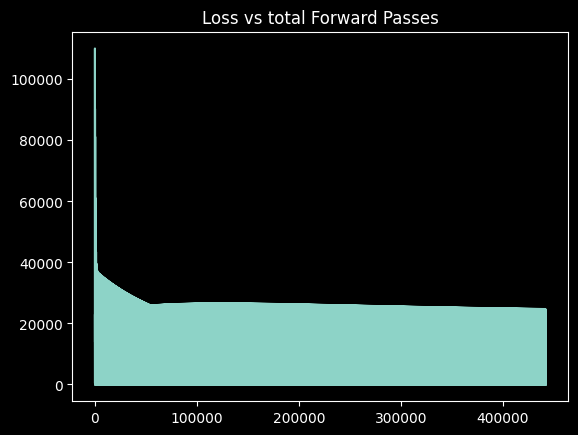

Weights after training are: [  10.49514478 -185.74559757  474.78490356  297.17409855  -36.9976714
 -100.46534105 -205.16313289  130.31886215  396.4626638   123.27232148]
bias after training are: [152.08760099]


In [ ]:
Question2 = StochasticGradientDescent(X,y,maxiterations=1000,activation=Linear,lossfunction=MeanSquaredLoss,learningrate=0.001)

In [ ]:
Question2.__predict__(X[0])

array([198.2841134])

In [ ]:
y[0]

151.0

## One Hot Encoding

One hot encoding is a technique that we use to represent categorical variables as numerical values in a machine learning model. It allows the use of categorical variables in models that require numerical input.

In [ ]:
def one_hot_encode(array):
    unique_values = np.unique(array)
    num_classes = len(unique_values)
    encoded_array = np.zeros((len(array), num_classes))
    for i, value in enumerate(array):
        index = np.where(unique_values == value)[0][0]
        encoded_array[i, index] = 1
    return encoded_array

In [ ]:
from sklearn.datasets import load_iris
df = load_iris()
X = df["data"]
y = df["target"]
multilevels = len(np.unique(y))
y = one_hot_encode(y)

## Question 3 on Multi Label Classification applied on the Iris dataset

Weights before training are: [[0.72539862 0.28644445 0.42160331]
 [0.58956803 0.59725375 0.49557926]
 [0.48257905 0.73060164 0.61964432]
 [0.00578852 0.94557498 0.99934365]]
bias before training are: [0.29426775]


Iterations: 100%|██████████| 500/500 [00:09<00:00, 53.31it/s]


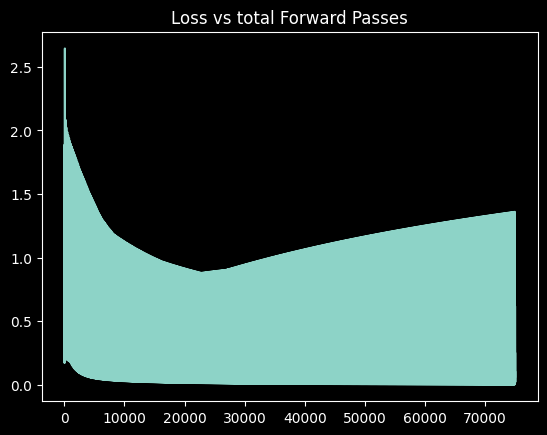

Weights after training are: [[ 1.38770258  1.1712293  -1.1254855 ]
 [ 2.27987231  0.48274021 -1.08021148]
 [-1.77793714  0.3425149   3.26824725]
 [-1.00167506 -0.07849694  3.03087914]]
bias after training are: [0.29426775]


In [ ]:
Question3 = StochasticGradientDescent(X,y,classificationfeatures=multilevels,maxiterations=500,activation=Softmax,lossfunction=CrossEntropyLoss,learningrate=0.001)

In [ ]:
Question3.__predict__(X[0])

array([[9.85806888e-01, 1.41930570e-02, 5.47396078e-08]])

In [ ]:
def func(X):
    x0 = X[0][0]
    x1 = X[0][1]
    x2 = X[0][2]
    max1 = max(x0, x1, x2)
    if max1 == x0:
        X[0][0] = 1
        X[0][1] = 0
        X[0][2] = 0
    elif max1 == x1:
        X[0][0] = 0
        X[0][1] = 1
        X[0][2] = 0
    else:
        X[0][0] = 0
        X[0][1] = 0
        X[0][2] = 1
    return X

In [ ]:
arr = Question3.__predict__(X[i])
arr = func(arr)

In [ ]:
arr

array([[1., 0., 0.]])

In [ ]:
y[0]

array([1., 0., 0.])

In [ ]:
arr[0] == y[0]

array([ True,  True,  True])

In [ ]:
acc = 0

In [ ]:
for i in range(len(X)):
    new_y = Question3.__predict__(X[i])
    new_y = func(new_y)
    for j in range(3):
        if new_y[0][j] != y[i][j]:
            acc += 1
            break

In [ ]:
1 - acc/len(X)

0.96